<a href="https://colab.research.google.com/github/peculab/DFTDescriptorPipeline/blob/main/examples/azoarene/azoarene_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!rm -rf /usr/local/lib/python3.11/dist-packages/descriptors

In [2]:
# ✅ Reset environment
%cd /content
import shutil, os, sys, importlib

# 🔁 Uninstall pip-installed descriptors
!pip uninstall -y descriptors

# 🔥 Clear cached modules
for k in list(sys.modules.keys()):
    if k.startswith("descriptors"):
        del sys.modules[k]

# 🧹 Remove previous repo
if os.path.exists("DFTDescriptorPipeline"):
    shutil.rmtree("DFTDescriptorPipeline")

/content


In [3]:
# ✅ Install required packages
!pip install morfeus-ml scikit-learn joblib matplotlib openpyxl

# ✅ Clone the latest repo
!git clone https://github.com/peculab/DFTDescriptorPipeline.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.0/95.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.8 MB/s eta 0:00:00
Cloning into 'DFTDescriptorPipeline'...
remote: Enumerating objects: 912, done.
remote: Counting objects: 100% (157/157), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 912 (delta 100), reused 51 (delta 36), pack-reused 755 (from 2)
Receiving objects: 100% (912/912), 37.57 MiB | 21.44 MiB/s, done.
Resolving deltas: 100% (532/532), done.
Updating files: 100% (87/87), done.


In [4]:
# ✅ Set module path
from morfeus import read_xyz, Sterimol
from morfeus.utils import get_radii

import shutil, os, sys, importlib
sys.path.insert(0, "/content/DFTDescriptorPipeline/descriptors")
import extractor_regr
import glob, os
importlib.reload(extractor_regr)

<module 'extractor_regr' from '/content/DFTDescriptorPipeline/descriptors/extractor_regr.py'>

Streaming output truncated to the last 5000 lines.
❌ ['Ar1_Ar_b', 'Ar2_L_C1_C2', 'Ar2_Ar_c'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_L_C1_C2', 'Ar2_Ar_e'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_L_C1_C2', 'Ar2_Ar_a'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_L_C1_C2', 'Ar2_Ar_b'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_L_C1_C2', 'Ar2_Ar_d'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_L_C1_C2', 'Ar2_Ar_f'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_L_C1_C2', 'Ar2_Ar_g'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_L_C1_C2', 'Ar2_Ar_Ster_L'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_L_C1_C2', 'Ar2_Ar_Ster_B1'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_L_C1_C2', 'Ar2_Ar_Ster_B5'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_Ar_c', 'Ar2_Ar_e'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_Ar_c', 'Ar2_Ar_a'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_Ar_c', 'Ar2_Ar_b'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_Ar_c', 'Ar2_Ar_d'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_Ar_c', 'Ar2_Ar_f'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_Ar_c', 'Ar2_Ar_g'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_Ar_c', 'Ar2_Ar_Ster_L'] | skipped
❌ ['Ar1_Ar_b', 'Ar2_Ar_c', 'Ar2_Ar_Ster_B1'] | skipped
❌ ['Ar1_A

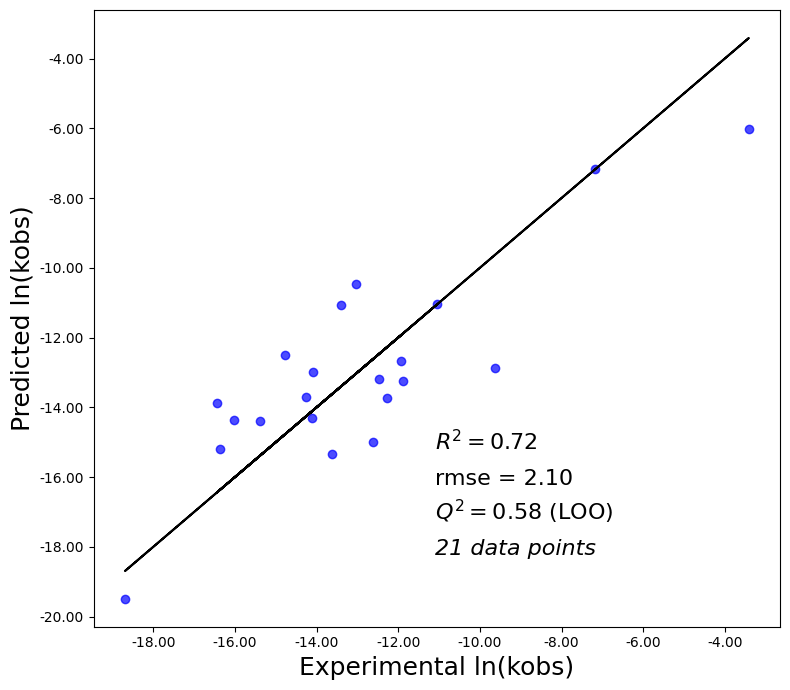


✅ Analysis complete!


In [5]:
# 指向原始資料（包含 Ar1、Ar2、...）
data_dir = "/content/DFTDescriptorPipeline/examples/azoarene"
xlsx_path = glob.glob(os.path.join(data_dir, "*.xlsx"))[0]
log_folder = os.path.join(data_dir, "logfiles")

# 一鍵執行
df, results, best_model = extractor_regr.run_full_pipeline(
    log_folder=log_folder,
    xlsx_path=xlsx_path,          # 直接用原檔
    max_features=3,
    target='ln(kobs)'
)

In [6]:
import pandas as pd

target = "ln(kobs)"
features = [c for c in df.columns if c.startswith("Ar") and "_" in c and not c.endswith(("_Ar", "_Ar_key", "_log_path", "_log_exists"))]

mask_missing = df[features + [target]].isna().any(axis=1)
dropped = df[mask_missing].copy()
dropped["missing_features"] = (
    df[features + [target]]
    .isna()
    .apply(lambda row: [c for c, v in row.items() if v], axis=1)
)

print(f"org dataset: {len(df)}")
print(f"missing dataset: {mask_missing.sum()}")
display(dropped[["Compound", "Ar1", "Ar2", "missing_features"]])

org dataset: 26
missing dataset: 5


,Compound,Ar1,Ar2,missing_features
12,A13,1,14,"[Ar2_Ar_NBO_C2, Ar2_Ar_NBO_=O, Ar2_Ar_NBO_-O, ..."
21,A22,23,21,"[Ar1_Ar_NBO_C2, Ar1_Ar_NBO_=O, Ar1_Ar_NBO_-O, ..."
22,A23,24,21,"[Ar1_Ar_NBO_C2, Ar1_Ar_NBO_=O, Ar1_Ar_NBO_-O, ..."
23,A24,20,23,"[Ar2_Ar_NBO_C2, Ar2_Ar_NBO_=O, Ar2_Ar_NBO_-O, ..."
24,A25,23,23,"[Ar1_Ar_NBO_C2, Ar1_Ar_NBO_=O, Ar1_Ar_NBO_-O, ..."


In [7]:
need = [c for c in df.columns if c.endswith(("_Ar_f","_Ar_g"))]
missing = df[need].isna().any(axis=1)
print("missing f/g：", int(missing.sum()))
display(df.loc[missing, ["Compound","Ar1","Ar2"] + need].head(10))

missing f/g： 5


,Compound,Ar1,Ar2,Ar1_Ar_f,Ar1_Ar_g,Ar2_Ar_f,Ar2_Ar_g
12,A13,1,14,2.0,2.0,NaN,NaN
21,A22,23,21,NaN,NaN,2.0,6.0
22,A23,24,21,NaN,NaN,2.0,6.0
23,A24,20,23,2.0,6.0,NaN,NaN
24,A25,23,23,NaN,NaN,NaN,NaN


Streaming output truncated to the last 5000 lines.
❌ ['Ar1_Ar_d', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_b', 'Ar2_Ar_f'] | skipped
❌ ['Ar1_Ar_d', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_b', 'Ar2_Ar_g'] | skipped
❌ ['Ar1_Ar_d', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_b', 'Ar2_Ar_Ster_L'] | skipped
❌ ['Ar1_Ar_d', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_b', 'Ar2_Ar_Ster_B1'] | skipped
❌ ['Ar1_Ar_d', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_b', 'Ar2_Ar_Ster_B5'] | skipped
❌ ['Ar1_Ar_d', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_d', 'Ar2_Ar_f'] | skipped
❌ ['Ar1_Ar_d', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_d', 'Ar2_Ar_g'] | skipped
❌ ['Ar1_Ar_d', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_d', 'Ar2_Ar_Ster_L'] | skipped
❌ ['Ar1_Ar_d', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_d', 'Ar2_Ar_Ster_B1'] | skipped
❌ ['Ar1_Ar_d', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_d', 'Ar2_Ar_Ster_B5'] | skipped
❌ ['Ar1_Ar_d', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_f', 'Ar2_Ar_g'] | skipped
❌ ['Ar1_Ar_d', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_f', 'Ar2_Ar_Ster_L'] | skipped
❌ ['Ar1_Ar_d', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_f', 'Ar2_Ar_Ster_B1'] | skipped
❌ ['Ar1_Ar_d', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_f', 'A

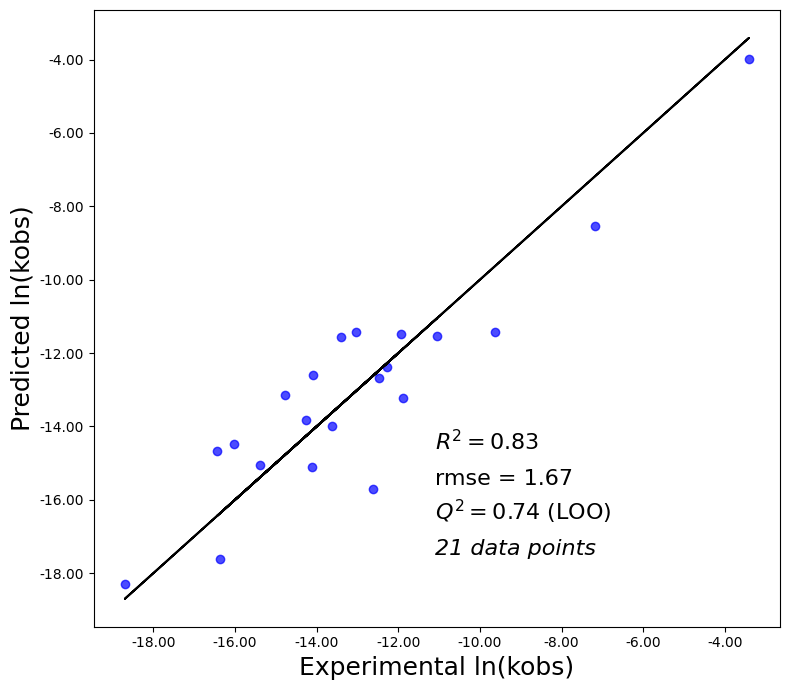


✅ Analysis complete!


In [ ]:
# 一鍵執行
df, results, best_model = extractor_regr.run_full_pipeline(
    log_folder=log_folder,
    xlsx_path=xlsx_path,          # 直接用原檔
    max_features=4,
    target='ln(kobs)'
)

Streaming output truncated to the last 5000 lines.
❌ ['Ar1_Ar_e', 'Ar1_Ar_Ster_B5', 'Ar2_Ar_LUMO', 'Ar2_Ar_c', 'Ar2_Ar_Ster_L'] | skipped
❌ ['Ar1_Ar_e', 'Ar1_Ar_Ster_B5', 'Ar2_L_C1_C2', 'Ar2_Ar_c', 'Ar2_Ar_Ster_B5'] | skipped
❌ ['Ar1_Ar_e', 'Ar1_Ar_Ster_B5', 'Ar2_Ar_b', 'Ar2_Ar_f', 'Ar2_Ar_Ster_B5'] | skipped
❌ ['Ar1_Ar_a', 'Ar1_Ar_b', 'Ar2_Ar_NBO_C2', 'Ar2_Ar_v_C=O', 'Ar2_Ar_a'] | skipped
❌ ['Ar1_Ar_a', 'Ar1_Ar_b', 'Ar2_Ar_NBO_C2', 'Ar2_Ar_v_C=O', 'Ar2_Ar_Ster_B1'] | skipped
❌ ['Ar1_Ar_a', 'Ar1_Ar_b', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_HOMO', 'Ar2_Ar_g'] | skipped
❌ ['Ar1_Ar_a', 'Ar1_Ar_b', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_c', 'Ar2_Ar_g'] | skipped
❌ ['Ar1_Ar_a', 'Ar1_Ar_b', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_b', 'Ar2_Ar_Ster_L'] | skipped
❌ ['Ar1_Ar_a', 'Ar1_Ar_b', 'Ar2_Ar_NBO_-O', 'Ar2_Ar_dp', 'Ar2_Ar_Ster_B5'] | skipped
❌ ['Ar1_Ar_a', 'Ar1_Ar_b', 'Ar2_Ar_NBO_-O', 'Ar2_Ar_HOMO', 'Ar2_Ar_Ster_L'] | skipped
❌ ['Ar1_Ar_a', 'Ar1_Ar_b', 'Ar2_Ar_v_C=O', 'Ar2_Ar_polar', 'Ar2_Ar_Ster_B1'] | skipped
❌ ['Ar1_Ar_a', 'Ar1

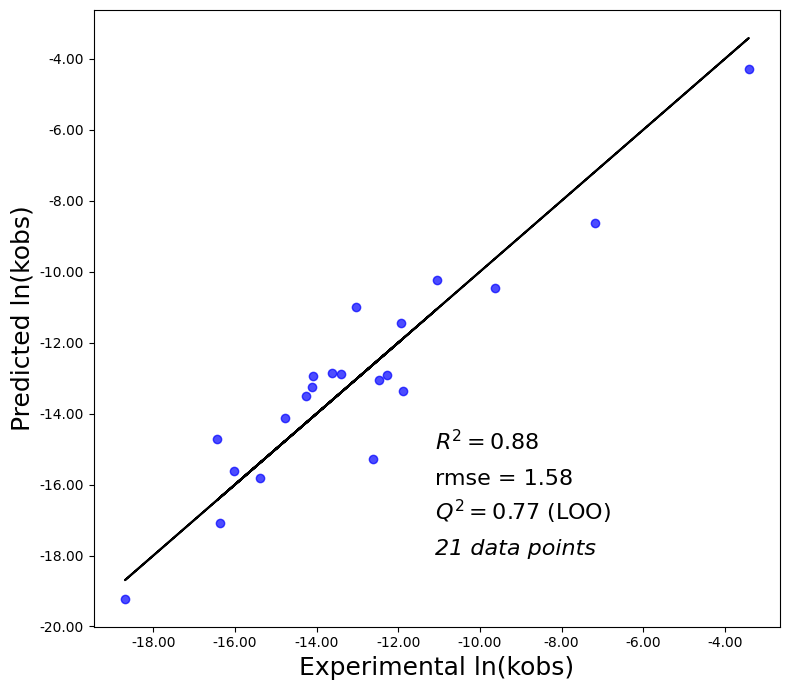


✅ Analysis complete!


In [ ]:
# 一鍵執行
df, results, best_model = extractor_regr.run_full_pipeline(
    log_folder=log_folder,
    xlsx_path=xlsx_path,          # 直接用原檔
    max_features=5,
    target='ln(kobs)'
)